In [26]:
import time
import torch 
from torch import nn, Tensor

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import ProbPath, AffineProbPath
from flow_matching.path.path_sample import PathSample
from flow_matching.utils import ModelWrapper
from flow_matching.solver import Solver, ODESolver

# visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# dataset
from sklearn.datasets import make_swiss_roll

In [14]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print('Using gpu')
else:
    device = 'cpu'
    print('Using cpu.')

Using gpu


### Dataset

Data shape: (5000, 2)


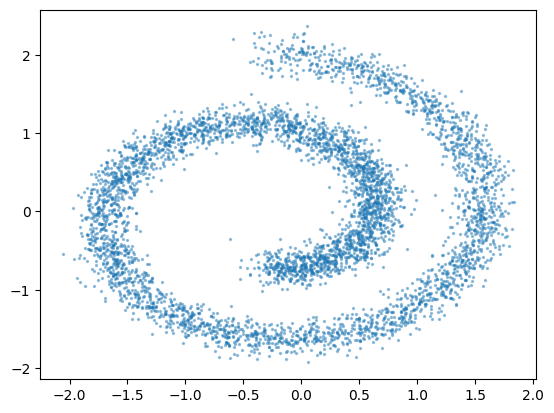

In [18]:
def get_data_batch(batch_size: int, noise: float = 0.8) -> Tensor:
    return Tensor(make_swiss_roll(batch_size, noise=noise)[0][:, [0, 2]])

X = get_data_batch(5000)
X = (X - X.mean(dim=0)) / X.std(dim=0)
X = X.numpy()
plt.scatter(X[:, 0], X[:, 1], s=2, alpha=0.4)

print("Data shape:", X.shape)

### Flow Model

In [15]:
class FlowModel(nn.Module):
    def __init__(self, dim=2, h=256):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        t = t.expand(*x.shape[:-1], 1) if t.dim() == 0 else t.view(-1, 1).expand(*x.shape[:-1], -1)
        return self.net(torch.cat((t, x), dim=-1))

velocity_model = FlowModel()
velocity_model.to(device)


FlowModel(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=256, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=256, out_features=2, bias=True)
  )
)

### Training


In [ ]:
# -- training arguments
lr = 0.001
batch_size = 4096
iterations = 20001
print_every = 2000 
hidden_dim = 512

# -- Initialize
# Initialize path
path = AffineProbPath(scheduler=CondOTScheduler())  # Conditional OT scheduler?

# Initialize model
velocity_model = FlowModel()
velocity_model.to(device)

optim = torch.optim.Adam(velocity_model.parameters(), lr=lr)


# -- train
losses = []

start_time = time.time()
for i in range(iterations):
    optim.zero_grad() 

    # sample data (user's responsibility): in this case, (X_0,X_1) ~ pi(X_0,X_1) = N(X_0|0,I)q(X_1)
    # x_1 = inf_train_gen(batch_size=batch_size, device=device) # sample data
    x_1 = get_data_batch(batch_size).to(device)
    x_0 = torch.randn_like(x_1).to(device)

    # sample time (user's responsibility)
    t = torch.rand(x_1.shape[0]).to(device) 

    # sample probability path
    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

    # flow matching l2 loss
    # cfm loss
    loss = torch.pow(velocity_model(path_sample.x_t,path_sample.t) - path_sample.dx_t, 2).mean()    # Monte Carlo estimate of flow matching loss

    # optimizer step
    loss.backward() # backward
    optim.step() # update
    losses.append(loss.item())

    # log loss
    if (i+1) % print_every == 0:
        elapsed = time.time() - start_time
        print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
              .format(i+1, elapsed*1000/print_every, loss.item())) 
        start_time = time.time()

| iter   2000 |  3.50 ms/step | loss   10.333 
| iter   4000 |  3.97 ms/step | loss    9.967 
| iter   6000 |  4.30 ms/step | loss    9.652 
| iter   8000 |  3.49 ms/step | loss    9.684 
| iter  10000 |  3.81 ms/step | loss   10.072 
| iter  12000 |  3.54 ms/step | loss   10.557 
| iter  14000 |  3.26 ms/step | loss    9.749 
| iter  16000 |  3.92 ms/step | loss   10.133 
| iter  18000 |  3.37 ms/step | loss   10.469 
| iter  20000 |  3.40 ms/step | loss    9.877 


Text(0, 0.5, 'Loss')

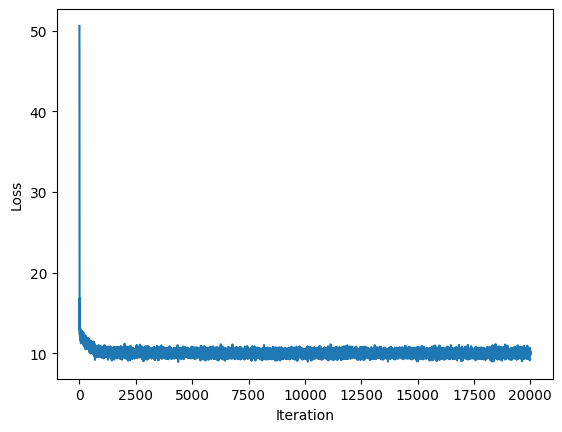

In [21]:
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')

### Sample from trained model

In [25]:
class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        return self.model(x, t, **extras)

wrapped_vf = WrappedModel(velocity_model)   # velocity field model

In [38]:
# step size for ode solver
step_size = 0.05

norm = cm.colors.Normalize(vmax=50, vmin=0)

batch_size = 50000  # batch size
eps_time = 1e-2
T = torch.linspace(0,1,10)  # sample times
T = T.to(device=device)

x_init = torch.randn((batch_size, 2), dtype=torch.float32, device=device)
solver = ODESolver(velocity_model=wrapped_vf)  # create an ODESolver class
sol = solver.sample(
    time_grid=T, 
    x_init=x_init, 
    method='midpoint',
    step_size=step_size,
    return_intermediates=True)  # sample from the model

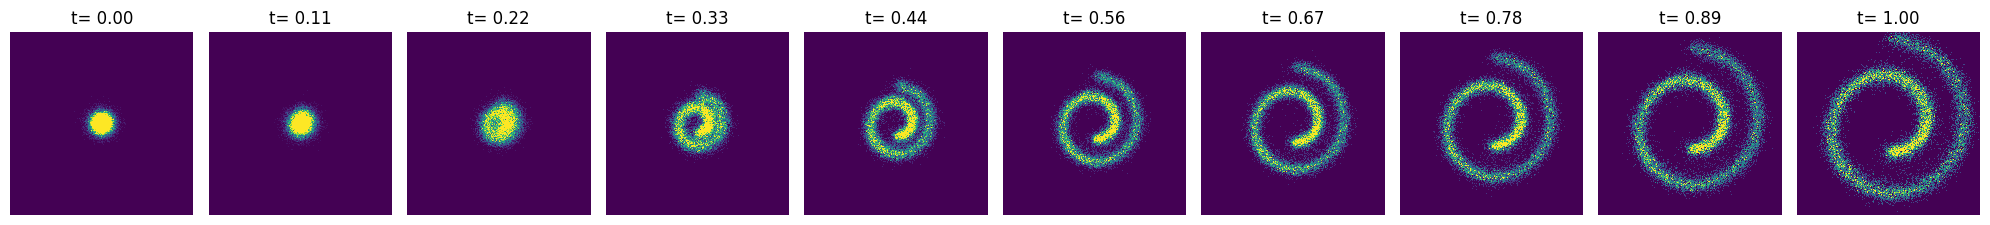

In [39]:
sol = sol.cpu().numpy()
T = T.cpu()

fig, axs = plt.subplots(1, 10,figsize=(20,20))

for i in range(10):
    H= axs[i].hist2d(sol[i,:,0], sol[i,:,1], 300, range=((-15, 15), (-15, 15)))
    
    cmin = 0.0
    cmax = torch.quantile(torch.from_numpy(H[0]), 0.99).item()
    
    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)
    
    _ = axs[i].hist2d(sol[i,:,0], sol[i,:,1], 300, range=((-15, 15), (-15, 15)), norm=norm)
    
    axs[i].set_aspect('equal')
    axs[i].axis('off')
    axs[i].set_title('t= %.2f' % (T[i]))
    
plt.tight_layout()
plt.show()

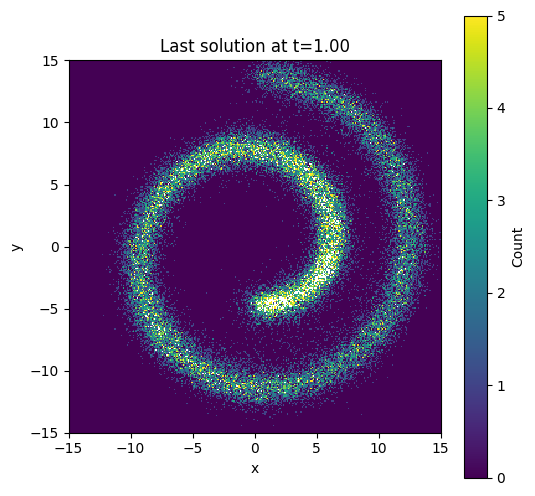

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(sol[-1, :, 0], sol[-1, :, 1], s=1, alpha=0.3)
plt.gca().set_aspect('equal')
plt.title(f'Last solution at t={float(T[-1]):.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.clf()

norm = cm.colors.Normalize(vmin=cmin, vmax=cmax)
plt.hist2d(
    sol[-1, :, 0],
    sol[-1, :, 1],
    bins=300,
    range=((-15, 15), (-15, 15)),
    cmap='viridis',
    cmin=cmin,
    cmax=cmax,
    norm=norm
)

plt.gca().set_aspect('equal')
plt.title(f'Last solution at t={float(T[-1]):.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Count')
plt.show()

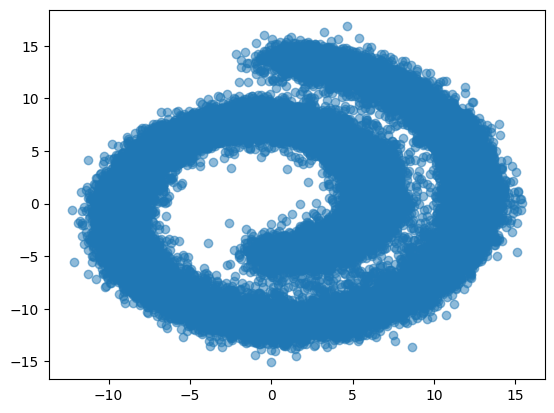

In [46]:
plt.plot(sol[-1, :, 0], sol[-1, :, 1], 'o', alpha=0.5, label='Final Sampled Points')

### Computing loglikelihood

In [41]:
from torch.distributions import Independent, Normal
from matplotlib import cm

In [42]:
# NOTE:
# Generate a grid of points in the 2D space and compute the likelihood of each point under the model.
# We will visualize this likelihood to understand how well the model captures the data distribution.
# Generates from -16 to 16 in both dimensions, 
# creating a grid of 200x200 points (40,000 total) for likelihood evaluation.
grid_size = 200
x_1 = torch.meshgrid(torch.linspace(-16, 16, grid_size), 
                     torch.linspace(-16, 16, grid_size))
x_1 = torch.stack([x_1[0].flatten(), x_1[1].flatten()], dim=1).to(device)

c:\Users\thanh\miniconda3\envs\deepl\lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4319.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [43]:
gaussian_log_density = Independent(
    Normal(torch.zeros(2, device=device), torch.ones(2, device=device)), 1).log_prob

# Ensure model and input are on the same device
velocity_model = velocity_model.to(device)
solver = ODESolver(velocity_model=velocity_model)

# compute with exact divergence
x0, exact_log_p = solver.compute_likelihood(
    x_1=x_1,
    method='midpoint',
    step_size=step_size,
    exact_divergence=True,
    log_p0=gaussian_log_density
)


c:\Users\thanh\miniconda3\envs\deepl\lib\site-packages\torchdiffeq\_impl\misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


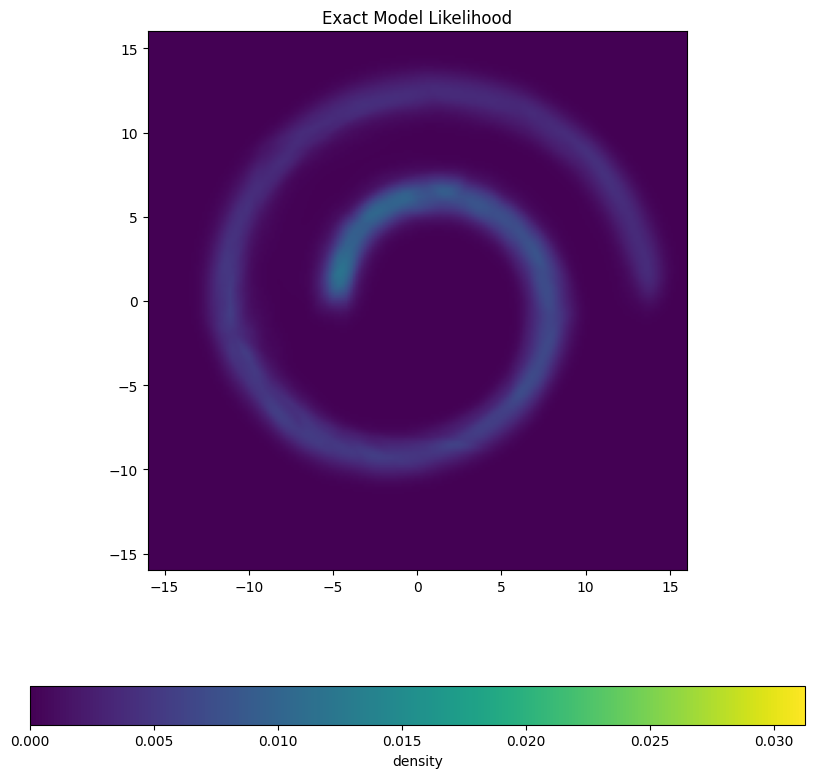

In [44]:
exact_likelihood = torch.exp(exact_log_p).cpu().reshape(grid_size, grid_size).detach().numpy()

cmin = 0.0
cmax = 1/32 # 1/32 is the gt likelihood value
norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)

fig, axs = plt.subplots(1, figsize=(10,10))
axs.imshow(exact_likelihood, extent=(-16, 16, -16, 16), origin='lower', cmap='viridis', norm=norm)
axs.set_title('Exact Model Likelihood')

fig.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), ax=axs, orientation='horizontal', label='density')
plt.show()